In [1]:
import os
os.chdir("/home/jacob/data_processing")

# import matplotlib
# matplotlib.use("pgf") 

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

fm.fontManager.addfont("/home/jacob/fonts/cmunrm.ttf")

# plt.rcParams.update({
#     "pgf.texsystem": "pdflatex",
#     "font.family": "serif",
#     "font.serif": ["CMU Serif"],
#     "font.size": 11,
#     "text.usetex": True,
#     "pgf.rcfonts": False,
# })

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

fm.fontManager.addfont("/home/jacob/fonts/cmunrm.ttf")
plt.rcParams["font.family"] = "CMU Serif"
plt.rcParams["font.size"] = 11

# sns.set_theme(
#     style="white",
#     context="paper",        
#     font="serif",
#     font_scale=1.0,
# )

In [2]:
base_dir = Path("/home/jacob/data_processing/data/")  

###
#data sets containing all lipids, and clustering score for peptides. Used for clustering score and phi vs titl angle
###

datasets_clustering  = {
    f"{p.parent.name}_clustering_df": p
    for p in sorted(base_dir.glob("*/Clustering_data/combined.csv"))
}

clustering_dfs = {
    label: pd.read_csv(path).assign(dataset=label)
    for label, path in datasets_clustering.items()
}

clustering_df = pd.concat(clustering_dfs.values(), ignore_index=True)

for label, data in clustering_dfs.items():
    globals()[label] = data

datasets_clustering_long  = {
    f"{p.parent.parent.name}_clustering_df": p
    for p in sorted(base_dir.glob("*_long/multi_peptide_long/combined.csv"))
}

clustering_long_dfs = {
    label: pd.read_csv(path).assign(dataset=label)
    for label, path in datasets_clustering_long.items()
}

clustering_long_df = pd.concat(clustering_long_dfs.values(), ignore_index=True)

for label, data in clustering_long_dfs.items():
    globals()[label] = data

for label, data in clustering_dfs.items():
    globals()[label] = data


double_clustering_df = clustering_df[clustering_df["dataset"].str.match(r"double_clustering\d")]
no_metal_double_clustering_df = clustering_df[clustering_df["dataset"].str.match(r"no_metal_double_clustering")]
no_metal_rut_pep_clustering_df = clustering_df[clustering_df["dataset"].str.match(r"no_metal_rut_pep_clustering")]
no_metal_rut_pep_clustering_no_15_df = clustering_df[clustering_df["dataset"].str.match(r"no_metal_rut_pep_clustering_(4|5|6|7|10|14|16|17|18|19|20)", na=False)]
rut_pep_clustering_df = clustering_df[clustering_df["dataset"].str.match(r"rut_pep_clustering")]
double_long_clustering_df = clustering_long_df[clustering_long_df["dataset"].str.match(r"double_long_clustering")]
no_metal_double_long_clustering_df = clustering_long_df[clustering_long_df["dataset"].str.match(r"no_metal_double_long_clustering")]
no_metal_rut_pep_long_clustering_df = clustering_long_df[clustering_long_df["dataset"].str.match(r"no_metal_rut_pep_long_clustering")]
no_metal_rut_pep_long_clustering_no_15_df = clustering_long_df[clustering_long_df["dataset"].str.match(r"no_metal_rut_pep_long_clustering_(5|16)", na=False)]
rut_pep_long_clustering_df = clustering_long_df[clustering_long_df["dataset"].str.match(r"rut_pep_long_clustering")]

###
#data sets containing all lipids and if they are near the pore or not based on selected or not selected (0 or 1) and contains tilt angle split into x and y components
###

datasets_pore = {
    f"{p.parent.parent.name}_pore_{p.parent.name}_df": p
    for p in sorted(base_dir.glob("*/*/centered_per_lipid_merged.csv"))
}

pore_dfs = {
    label: pd.read_csv(path).assign(dataset=label)
    for label, path in datasets_pore.items()
}

pore_df = pd.concat(pore_dfs.values(), ignore_index=True)

# print(pore_df["dataset"].unique())

for label, data in pore_dfs.items():
    globals()[label] = data

double_pore_df = pore_df[pore_df["dataset"].str.match(r"double_pore_\d")]
no_metal_double_pore_df = pore_df[pore_df["dataset"].str.match(r"no_metal_double_pore")]
no_metal_rut_pep_pore_df = pore_df[pore_df["dataset"].str.match(r"no_metal_rut_pep_pore")]
no_metal_rut_pep_pore_no_15_df = pore_df[pore_df["dataset"].str.match(r"no_metal_rut_pep_pore_(4|5|6|7|10|14|16|17|18|19|20)", na=False)]
rut_pep_pore_df = pore_df[pore_df["dataset"].str.match(r"rut_pep_pore")]
double_long_pore_df = pore_df[pore_df["dataset"].str.match(r"double_long_pore")]
no_metal_double_long_pore_df = pore_df[pore_df["dataset"].str.match(r"no_metal_double_long_pore")]
no_metal_rut_pep_long_pore_df = pore_df[pore_df["dataset"].str.match(r"no_metal_rut_pep_long_pore")]
no_metal_rut_pep_long_pore_no_15_df = pore_df[pore_df["dataset"].str.match(r"no_metal_rut_pep_long_pore_(5|16)")]
rut_pep_long_pore_df = pore_df[pore_df["dataset"].str.match(r"rut_pep_long_pore")]


###
#data sets containing peptide proximity to the pore in the membrane per system (peptide_summary.csv)
###

datasets_pep_sum = {
    f"{p.parent.parent.name}_pep_sum_{p.parent.name}_df": p
    for p in sorted(base_dir.glob("*/*/centered_peptide_summary.csv"))
}

pep_sum_dfs = {
    label: pd.read_csv(path).assign(dataset=label)
    for label, path in datasets_pep_sum.items()
}

pep_sum_df = pd.concat(pep_sum_dfs.values(), ignore_index=True)

# print(pep_sum_df)

for label, data in pep_sum_dfs.items():
    globals()[label] = data

double_pep_sum_df = pep_sum_df[pep_sum_df["dataset"].str.match(r"double_pep_sum_\d")]
no_metal_double_pep_sum_df = pep_sum_df[pep_sum_df["dataset"].str.match(r"no_metal_double_pep_sum")]
no_metal_rut_pep_pep_sum_df = pep_sum_df[pep_sum_df["dataset"].str.match(r"no_metal_rut_pep_pep_sum")]
no_metal_rut_pep_pep_sum_no_15_df = pep_sum_df[pep_sum_df["dataset"].str.match(r"no_metal_rut_pep_pep_sum_(4|5|6|7|10|14|16|17|18|19|20)", na=False)]
rut_pep_pep_sum_df = pep_sum_df[pep_sum_df["dataset"].str.match(r"rut_pep_pep_sum")]
double_long_pep_sum_df = pep_sum_df[pep_sum_df["dataset"].str.match(r"double_long_pep_sum")]
no_metal_double_long_pep_sum_df = pep_sum_df[pep_sum_df["dataset"].str.match(r"no_metal_double_long_pep_sum")]
no_metal_rut_pep_long_pep_sum_df = pep_sum_df[pep_sum_df["dataset"].str.match(r"no_metal_rut_pep_long_pep_sum")]
no_metal_rut_pep_long_pep_sum_no_15_df = pep_sum_df[pep_sum_df["dataset"].str.match(r"no_metal_rut_pep_long_pep_sum_(5|16)", na=False)]
rut_pep_long_pep_sum_df = pep_sum_df[pep_sum_df["dataset"].str.match(r"rut_pep_long_pep_sum")]

# print(rut_pep_peptide_df)

###
# data sets containing all raw peptide data per system (peptide_per_frame.csv)
###

datasets_ppf = {
    f"{p.parent.parent.name}_peptide_{p.parent.name}_df": p
    for p in sorted(base_dir.glob("*/*/centered_peptide_per_frame.csv"))
}

ppf_dfs = {
    label: pd.read_csv(path).assign(dataset=label)
    for label, path in datasets_ppf.items()
}

ppf_df = pd.concat(ppf_dfs.values(), ignore_index=True)

# print(ppf_df)

for label, data in ppf_dfs.items():
    globals()[label] = data

double_ppf_df = ppf_df[ppf_df["dataset"].str.match(r"double_ppf_\d")]
no_metal_double_ppf_df = ppf_df[ppf_df["dataset"].str.match(r"no_metal_double_ppf")]
no_metal_rut_pep_ppf_df = ppf_df[ppf_df["dataset"].str.match(r"no_metal_rut_pep_ppf")]
no_metal_rut_pep_ppf_no_15_df = ppf_df[ppf_df["dataset"].str.match(r"no_metal_rut_pep_ppf_(4|5|6|7|10|14|16|17|18|19|20)", na=False)]
rut_pep_ppf_df = ppf_df[ppf_df["dataset"].str.match(r"rut_pep_ppf")]
double_long_ppf_df = ppf_df[ppf_df["dataset"].str.match(r"double_long_ppf")]
no_metal_double_long_ppf_df = ppf_df[ppf_df["dataset"].str.match(r"no_metal_double_long_ppf")]
no_metal_rut_pep_long_ppf_df = ppf_df[ppf_df["dataset"].str.match(r"no_metal_rut_pep_long_ppf")]
no_metal_rut_pep_long_ppf_no_15_df = ppf_df[ppf_df["dataset"].str.match(r"no_metal_rut_pep_long_ppf_(5|16)", na=False)]
rut_pep_long_ppf_df = ppf_df[ppf_df["dataset"].str.match(r"rut_pep_long_ppf")]


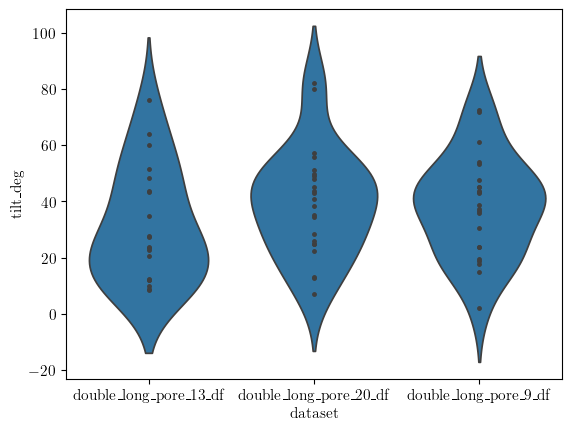

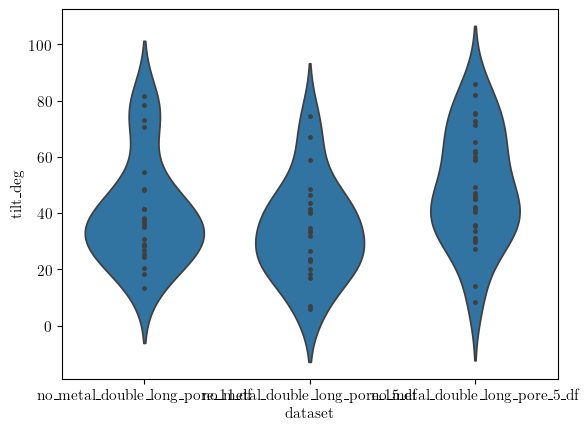

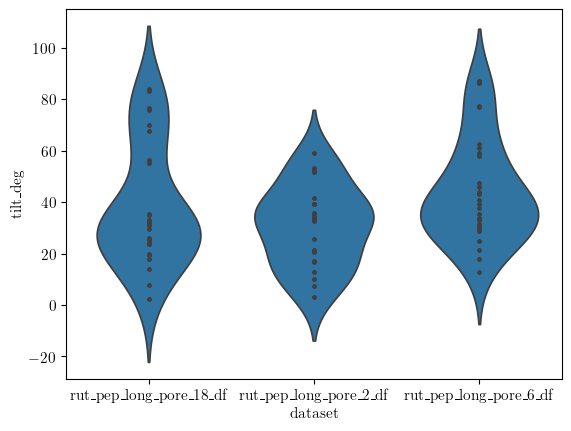

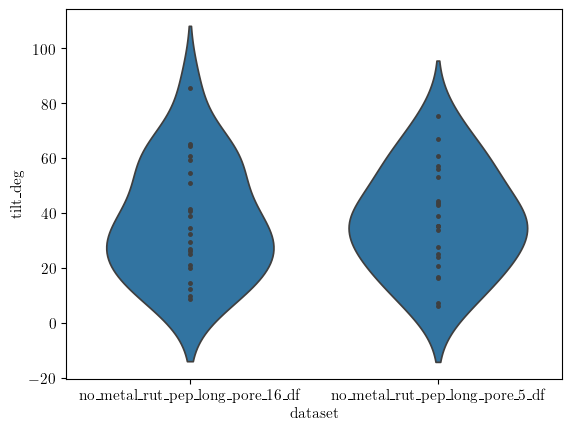

In [3]:
sns.violinplot(
    data=double_long_pore_df[double_long_pore_df["selected"] == 1],
    # data=lipid_5_df,
    x="dataset",
    y="tilt_deg",
    # bw_adjust=0.2,
    # inner="stick",
    # split=True,
    # hue="selected",
    inner="point", 
    # gap=.1,
    # col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.show()

sns.violinplot(
    data=no_metal_double_long_pore_df[no_metal_double_long_pore_df["selected"] == 1],
    # data=lipid_5_df,
    x="dataset",
    y="tilt_deg",
    # bw_adjust=0.2,
    inner="point",
    # split=True,
    # hue="selected", 
    gap=.1,
    # col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.show()
sns.violinplot(
    data=rut_pep_long_pore_df[rut_pep_long_pore_df["selected"] == 1],
    # data=lipid_5_df,
    x="dataset",
    y="tilt_deg",
    # split=True,
    # hue="selected",
    inner="point", 
    gap=.1,
    # col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.show()

sns.violinplot(
    data=no_metal_rut_pep_long_pore_no_15_df[no_metal_rut_pep_long_pore_no_15_df["selected"] == 1],
    # data=lipid_5_df,
    x="dataset",
    y="tilt_deg",
    # split=True,
    # hue="selected",
    inner="point", 
    gap=.1,
    # col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.show()

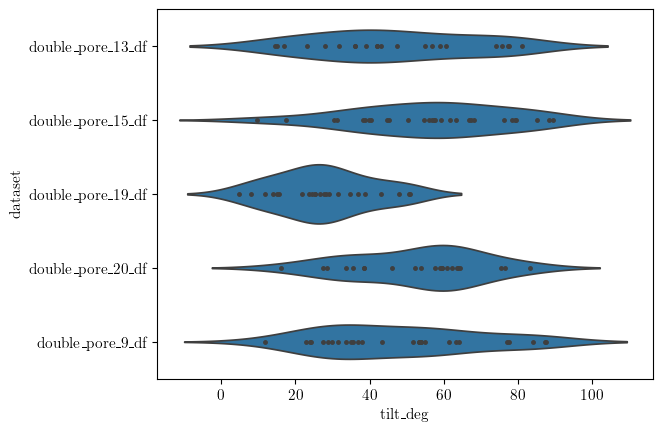

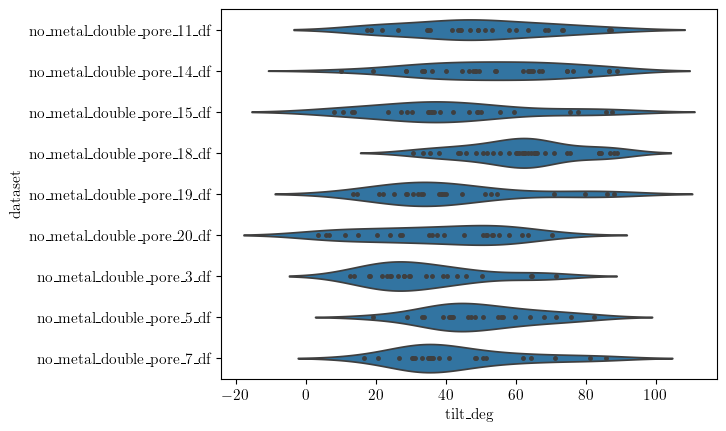

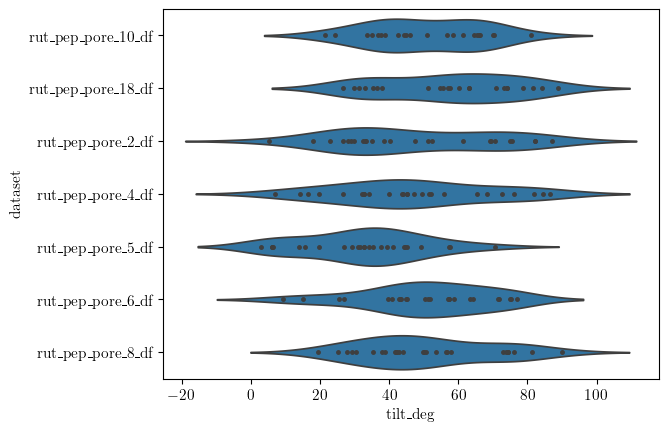

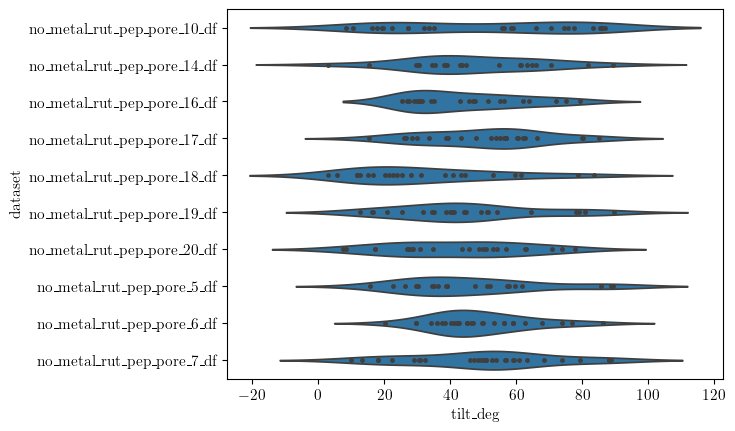

In [4]:
sns.violinplot(
    data=double_pore_df[double_pore_df["selected"] == 1],
    # data=lipid_5_df,
    y="dataset",
    x="tilt_deg",
    # bw_adjust=0.2,
    # inner="stick",
    # split=True,
    # hue="selected",
    inner="point", 
    # gap=.1,
    # col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.show()

sns.violinplot(
    data=no_metal_double_pore_df[no_metal_double_pore_df["selected"] == 1],
    # data=lipid_5_df,
    y="dataset",
    x="tilt_deg",
    # bw_adjust=0.2,
    inner="point",
    # split=True,
    # hue="selected", 
    gap=.1,
    # col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.show()
sns.violinplot(
    data=rut_pep_pore_df[rut_pep_pore_df["selected"] == 1],
    # data=lipid_5_df,
    y="dataset",
    x="tilt_deg",
    # split=True,
    # hue="selected",
    inner="point", 
    gap=.1,
    # col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.show()

sns.violinplot(
    data=no_metal_rut_pep_pore_no_15_df[no_metal_rut_pep_pore_no_15_df["selected"] == 1],
    # data=lipid_5_df,
    y="dataset",
    x="tilt_deg",
    # split=True,
    # hue="selected",
    inner="point", 
    gap=.1,
    # col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.show()

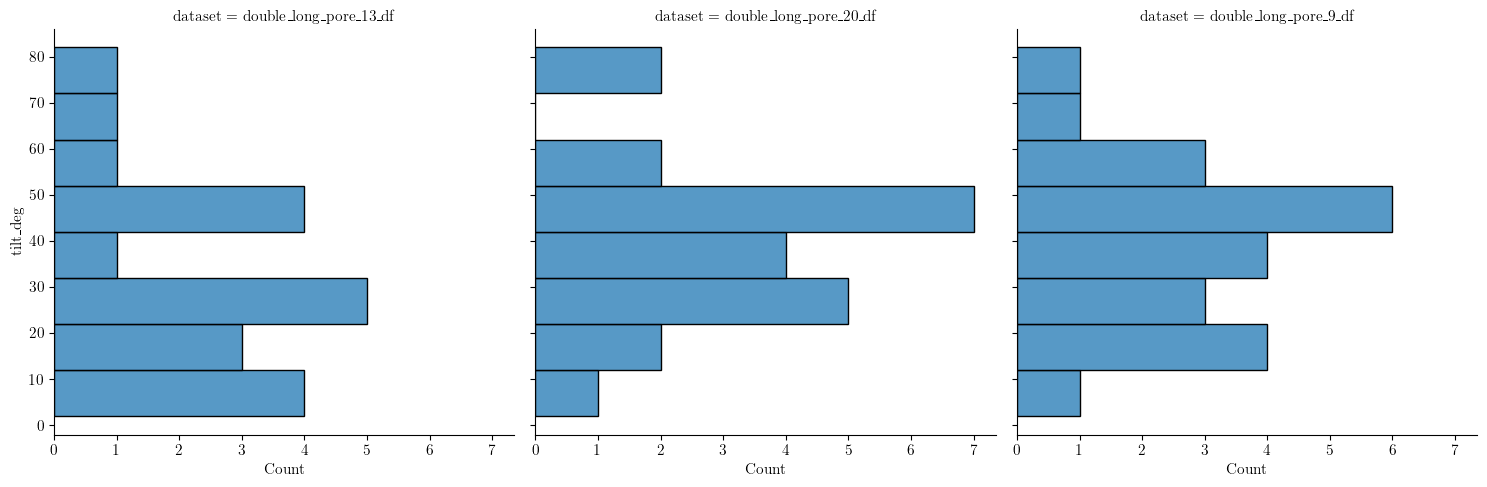

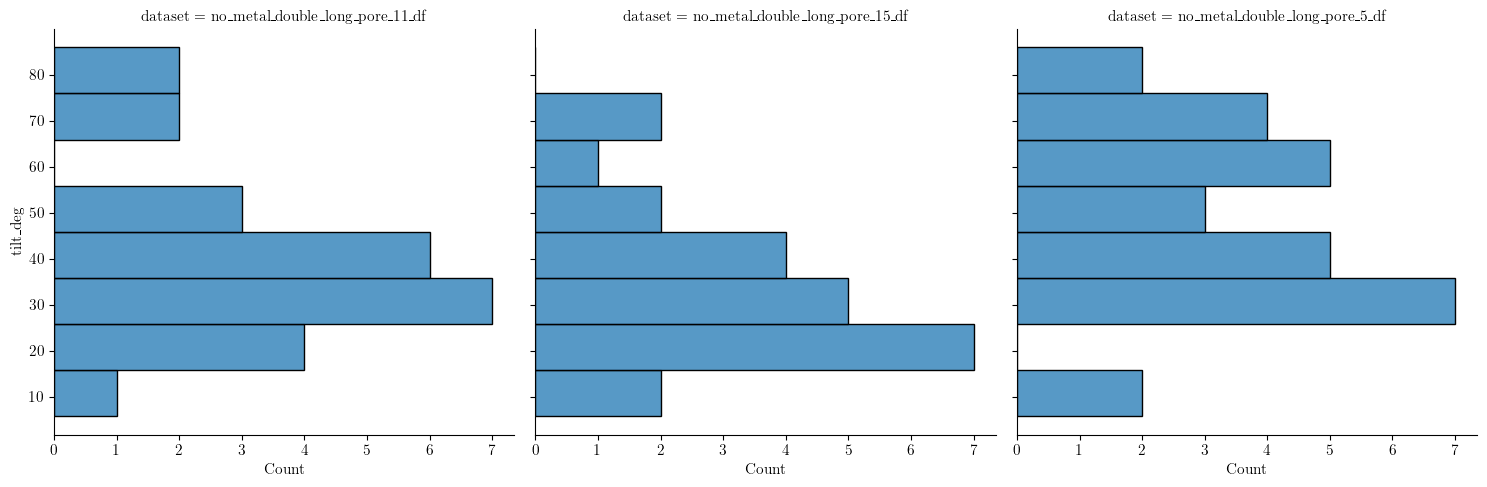

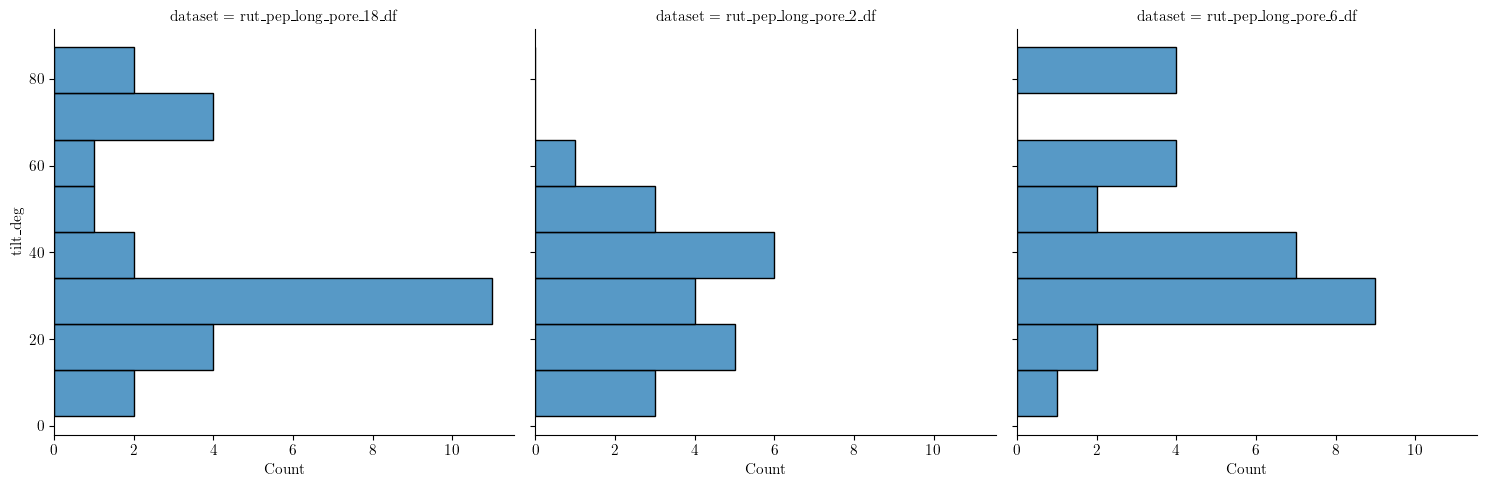

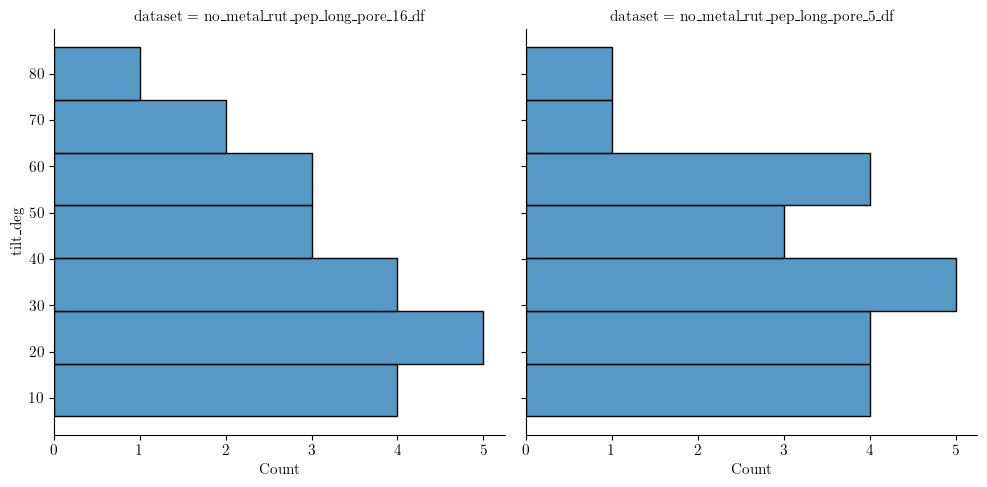

In [5]:
# combined = pd.concat([
#     no_metal_rut_pep_long_pore_no_15_df[no_metal_rut_pep_long_pore_no_15_df["selected"] == 1].assign(dataset="no metal single"),
#     rut_pep_long_pore_df[rut_pep_long_pore_df["selected"] == 1].assign(dataset="single"),
#     no_metal_double_long_pore_df[no_metal_double_long_pore_df["selected"] == 1].assign(dataset="no metal double"),
#     double_long_pore_df[double_long_pore_df["selected"] == 1].assign(dataset="double")
# ])

sns.displot(
    data=double_long_pore_df[double_long_pore_df["selected"] == 1],
    y="tilt_deg",
    # y="",
    col="dataset",
    # bw_adjust=0.2,
    # inner="stick",
    # split=True,
    # hue="selected",
    # inner="point", 
    # gap=.1,
    # col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.show()

sns.displot(
    data=no_metal_double_long_pore_df[no_metal_double_long_pore_df["selected"] == 1],
    # data=lipid_5_df,
    # x="dataset",
    y="tilt_deg",
    col="dataset",
    # bw_adjust=0.2,
    # inner="point",
    # split=True,
    # hue="selected", 
    # gap=.1,
    # col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.show()

sns.displot(
    data=rut_pep_long_pore_df[rut_pep_long_pore_df["selected"] == 1],
    # data=lipid_5_df,
    # x="dataset",
    y="tilt_deg",
    # split=True,
    # hue="selected",
    # inner="point", 
    # gap=.1,
    col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.show()

sns.displot(
    data=no_metal_rut_pep_long_pore_no_15_df[no_metal_rut_pep_long_pore_no_15_df["selected"] == 1],
    # data=lipid_5_df,
    # x="dataset",
    y="tilt_deg",
    # split=True,
    # hue="selected",
    # inner="point", 
    # gap=.1,
    col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.show()

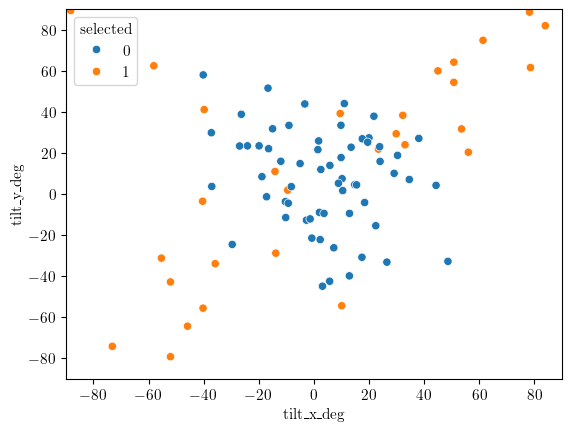

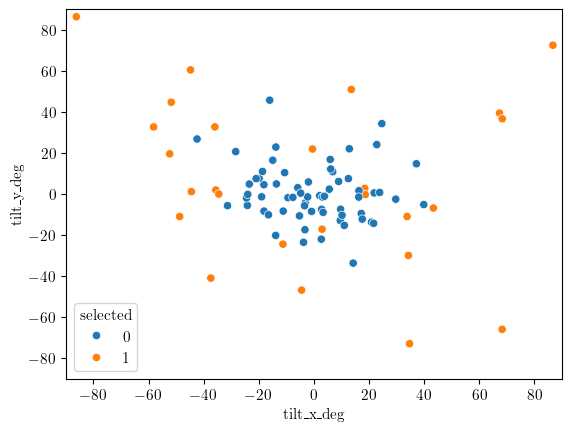

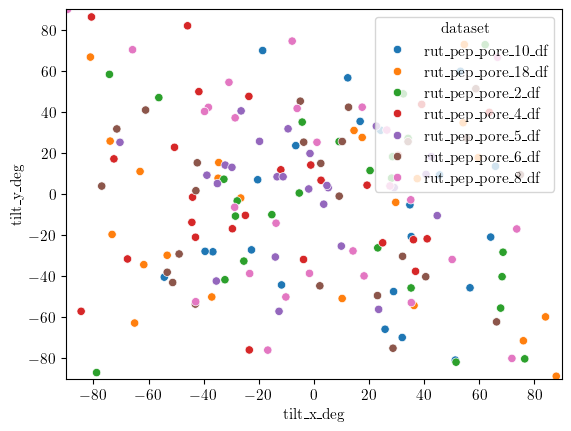

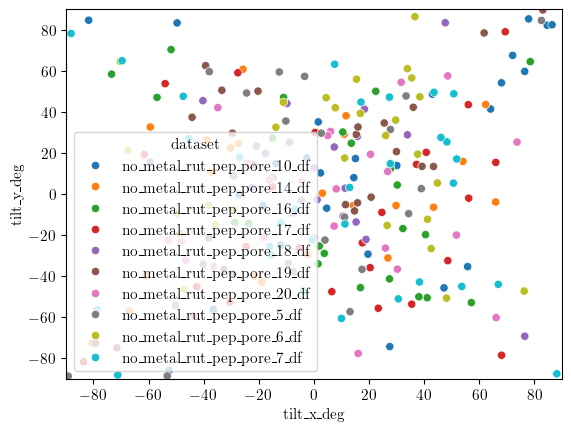

In [12]:
# combined = pd.concat([
#     no_metal_rut_pep_long_pore_no_15_df[no_metal_rut_pep_long_pore_no_15_df["selected"] == 1].assign(dataset="no metal single"),
#     rut_pep_long_pore_df[rut_pep_long_pore_df["selected"] == 1].assign(dataset="single"),
#     no_metal_double_long_pore_df[no_metal_double_long_pore_df["selected"] == 1].assign(dataset="no metal double"),
#     double_long_pore_df[double_long_pore_df["selected"] == 1].assign(dataset="double")
# ])

# sns.scatterplot(
    # data=double_pore_15_df[double_pore_15_df["selected"] == 1],
    # y="tilt_y_deg",
    # x="tilt_x_deg",
    # # col="dataset",
    # # bw_adjust=0.2,
    # # inner="stick",
    # # split=True,
    # # hue="dataset",
    # # inner="point", 
    # # gap=.1,
    # # col="dataset", 
    # # hue="dataset",
    # # label="5",
    # )

sns.scatterplot(
    data=double_pore_15_df,
    y="tilt_y_deg",
    x="tilt_x_deg",
    # col="dataset",
    # bw_adjust=0.2,
    # inner="stick",
    # split=True,
    hue="selected",
    # inner="point", 
    # gap=.1,
    # col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.ylim(-90, 90)
plt.xlim(-90, 90)
plt.show()

sns.scatterplot(
    data=no_metal_double_pore_11_df,
    y="tilt_y_deg",
    x="tilt_x_deg",
    # col="dataset",
    # bw_adjust=0.2,
    # inner="stick",
    # split=True,
    hue="selected",
    # inner="point", 
    # gap=.1,
    # col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.ylim(-90, 90)
plt.xlim(-90, 90)
plt.show()

sns.scatterplot(
    data=rut_pep_pore_df[rut_pep_pore_df["selected"] == 1],
    y="tilt_y_deg",
    x="tilt_x_deg",
    # col="dataset",
    # bw_adjust=0.2,
    # inner="stick",
    # split=True,
    hue="dataset",
    # inner="point", 
    # gap=.1,
    # col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.ylim(-90, 90)
plt.xlim(-90, 90)
plt.show()

sns.scatterplot(
    data=no_metal_rut_pep_pore_no_15_df[no_metal_rut_pep_pore_no_15_df["selected"] == 1],
    y="tilt_y_deg",
    x="tilt_x_deg",
    # col="dataset",
    # bw_adjust=0.2,
    # inner="stick",
    # split=True,
    hue="dataset",
    # inner="point", 
    # gap=.1,
    # col="dataset", 
    # hue="dataset",
    # label="5",
    )

plt.ylim(-90, 90)
plt.xlim(-90, 90)
plt.show()

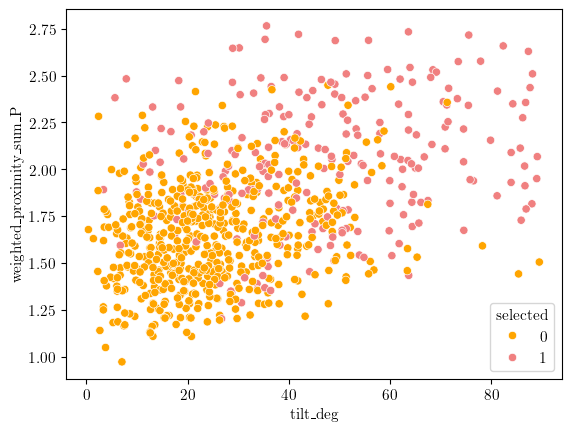

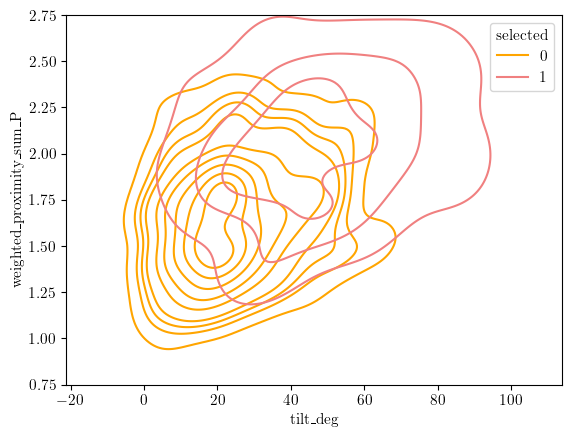

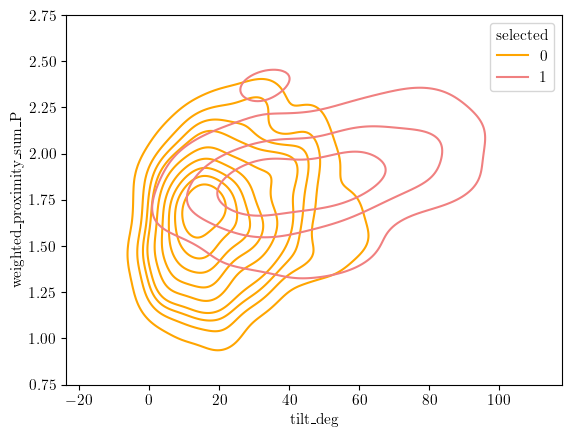

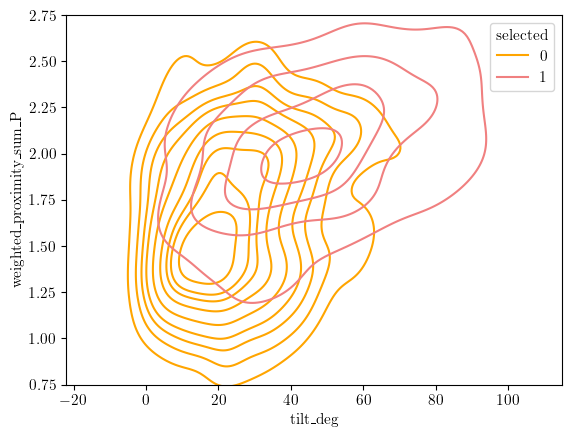

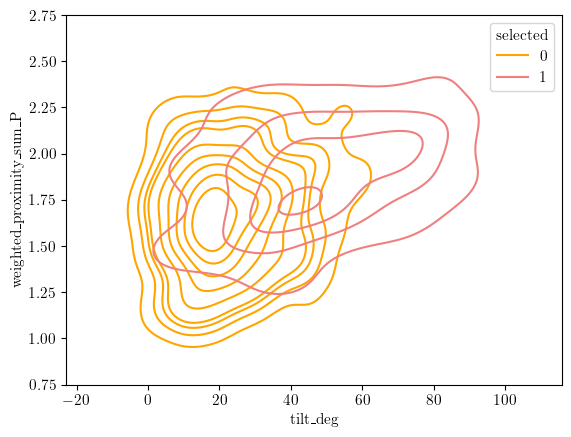

In [7]:
# fig, ax = plt.subplots()

# sns.scatterplot(
#     data=double_long_clustering_df,
#     # title="double_pore_df",
#     x="angle_folded_0_90_deg",
#     y="weighted_proximity_sum_P", 
#     # col="dataset", 
#     # hue="selected",
#     # label="metal",
#     # ax=ax,
#     # binwidth=10,
#     palette=["orange", "lightcoral"],
#     # fill=True,
#     legend=True,
#     )

sns.scatterplot(
    data=no_metal_double_pore_df,
    # title="double_pore_df",
    x="tilt_deg",
    y="weighted_proximity_sum_P", 
    # col="dataset", 
    hue="selected",
    # label="metal",
    # ax=ax,
    # binwidth=10,
    palette=["orange", "lightcoral"],
    # fill=True,
    legend=True,
    )

plt.show()

sns.kdeplot(
    data=no_metal_double_pore_df,
    # title="double_pore_df",
    x="tilt_deg",
    y="weighted_proximity_sum_P", 
    # col="dataset", 
    hue="selected",
    # label="metal",
    # ax=ax,
    # binwidth=10,
    palette=["orange", "lightcoral"],
    # fill=True,
    legend=True,
    )

# plt.xlim(0.75, 2.75)
plt.ylim(0.75, 2.75)
plt.show()

sns.kdeplot(
    data=double_pore_df,
    # title="double_pore_df",
    x="tilt_deg",
    y="weighted_proximity_sum_P", 
    # col="dataset", 
    hue="selected",
    # label="metal",
    # ax=ax,
    # binwidth=10,
    palette=["orange", "lightcoral"],
    # fill=True,
    legend=True,
    )

plt.ylim(0.75, 2.75)
plt.show()

sns.kdeplot(
    data=no_metal_rut_pep_pore_no_15_df,
    # title="double_pore_df",
    x="tilt_deg",
    y="weighted_proximity_sum_P", 
    # col="dataset", 
    hue="selected",
    # label="metal",
    # ax=ax,
    # binwidth=10,
    palette=["orange", "lightcoral"],
    # fill=True,
    legend=True,
    )

plt.ylim(0.75, 2.75)
plt.show()

sns.kdeplot(
    data=rut_pep_pore_df,
    # title="double_pore_df",
    x="tilt_deg",
    y="weighted_proximity_sum_P", 
    # col="dataset", 
    hue="selected",
    # label="metal",
    # ax=ax,
    # binwidth=10,
    palette=["orange", "lightcoral"],
    # fill=True,
    legend=True,
    )

plt.ylim(0.75, 2.75)
plt.show()

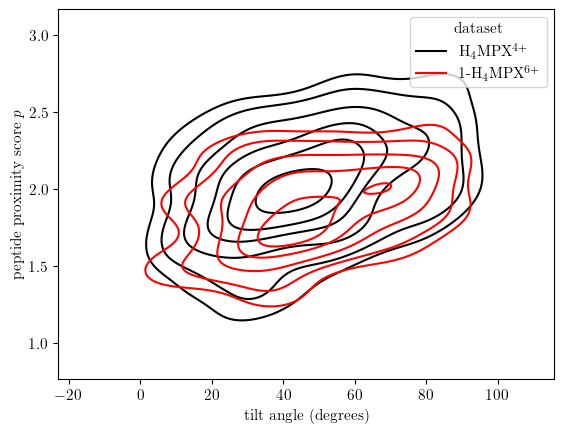

In [8]:
# fig, ax = plt.subplots()

# sns.scatterplot(
#     data=double_long_clustering_df,
#     # title="double_pore_df",
#     x="angle_folded_0_90_deg",
#     y="weighted_proximity_sum_P", 
#     # col="dataset", 
#     # hue="selected",
#     # label="metal",
#     # ax=ax,
#     # binwidth=10,
#     palette=["orange", "lightcoral"],
#     # fill=True,
#     legend=True,
#     )

# sns.scatterplot(
#     data=no_metal_double_pore_df[no_metal_double_pore_df["selected"] == 1],
#     # title="double_pore_df",
#     x="tilt_deg",
#     y="weighted_proximity_sum_P", 
#     # col="dataset", 
#     hue="selected",
#     # label="metal",
#     # ax=ax,
#     # binwidth=10,
#     # palette=["orange", "lightcoral"],
#     # fill=True,
#     legend=False,
#     )

# sns.scatterplot(
#     data=double_pore_df[double_pore_df["selected"] == 1],
#     # title="double_pore_df",
#     x="tilt_deg",
#     y="weighted_proximity_sum_P", 
#     # col="dataset", 
#     # hue="selected",
#     # label="metal",
#     # ax=ax,
#     # binwidth=10,
#     palette=["orange", "lightcoral"],
#     # fill=True,
#     legend=False,
#     # levels=[0.2, 0.4, 0.6, 0.8, 0.95],
#     # cbar=True,
#     )

# sns.kdeplot(
#     data=no_metal_double_pore_df[no_metal_double_pore_df["selected"] == 1],
#     # title="double_pore_df",
#     x="tilt_deg",
#     y="weighted_proximity_sum_P", 
#     # col="dataset", 
#     # hue="selected",
#     # label="metal",
#     # ax=ax,
#     # binwidth=10,
#     # palette=["orange", "lightcoral"],
#     # fill=True,
#     legend=False,
#     levels=[0.1, 0.2, 0.4, 0.6, 0.8, 0.95],
#     # cbar=True,
#     ylabel="peptide proximity to pore",
#     )

# # plt.xlim(0.75, 2.75)
# plt.ylim(0.75, 3)
# plt.show()

# sns.kdeplot(
#     data=double_pore_df[double_pore_df["selected"] == 1],
#     # title="double_pore_df",
#     x="tilt_deg",
#     y="weighted_proximity_sum_P", 
#     # col="dataset", 
#     # hue="selected",
#     # label="metal",
#     # ax=ax,
#     # binwidth=10,
#     palette=["orange", "lightcoral"],
#     # fill=True,
#     legend=False,
#     levels=[0.1, 0.2, 0.4, 0.6, 0.8, 0.95],
#     # cbar=True,
#     )

# plt.ylabel("peptide proximity score")
# plt.ylim(0.75, 3)
# # plt.xlim(-90, 180)
# plt.show()

combined_rut = pd.concat([no_metal_rut_pep_pore_no_15_df[no_metal_rut_pep_pore_no_15_df["selected"] == 1].assign(dataset="H$_4$MPX$^{4+}$"), rut_pep_pore_df[rut_pep_pore_df["selected"] == 1].assign(dataset="1-H$_4$MPX$^{6+}$")])

sns.kdeplot(
    data=combined_rut,
    # title="double_pore_df",
    x="tilt_deg",
    y="weighted_proximity_sum_P", 
    # col="dataset", 
    hue="dataset",
    # label="metal",
    # ax=ax,
    # binwidth=10,
    palette=["black", "red"],
    # fill=True,
    legend=True,
    levels=[0.1, 0.2, 0.4, 0.6, 0.8, 0.95],
    )

plt.ylabel("peptide proximity score $p$")
plt.xlabel("tilt angle (degrees)")
# plt.savefig("/home/jacob/data_processing/data/plots/kde_plot_single.pgf")
plt.savefig("/home/jacob/data_processing/data/plots/kde_plot_single.pdf", bbox_inches="tight")
plt.show()

# sns.kdeplot(
#     data=no_metal_rut_pep_pore_no_15_df[no_metal_rut_pep_pore_no_15_df["selected"] == 1],
#     # title="double_pore_df",
#     x="tilt_deg",
#     y="weighted_proximity_sum_P", 
#     # col="dataset", 
#     # hue="selected",
#     # label="metal",
#     # ax=ax,
#     # binwidth=10,
#     # palette=["orange", "lightcoral"],
#     # fill=True,
#     legend=False,
#     levels=[0.1, 0.2, 0.4, 0.6, 0.8, 0.95],
#     )

# # plt.ylim(0.75, 2.75)
# # plt.show()

# sns.kdeplot(
#     data=rut_pep_pore_df[rut_pep_pore_df["selected"] == 1],
#     # title="double_pore_df",
#     x="tilt_deg",
#     y="weighted_proximity_sum_P", 
#     # col="dataset", 
#     # hue="selected",
#     # label="metal",
#     # ax=ax,
#     # binwidth=10,
#     palette=["orange", "lightcoral"],
#     # fill=True,
#     legend=False,
#     levels=[0.1, 0.2, 0.4, 0.6, 0.8, 0.95],
#     )

# plt.ylim(0.75, 3)
# plt.show()

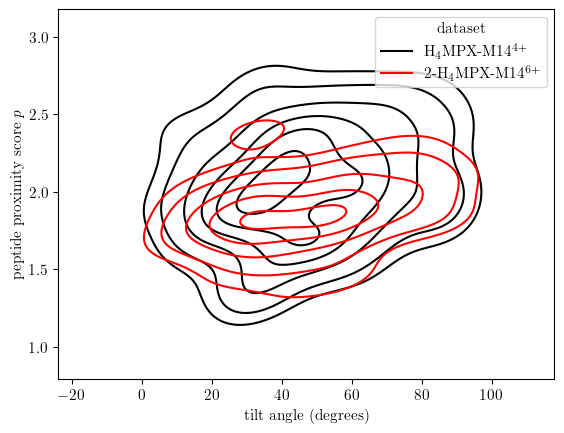

In [9]:
combined_double = pd.concat([no_metal_double_pore_df[no_metal_double_pore_df["selected"] == 1].assign(dataset="H$_4$MPX-M14$^{4+}$"), double_pore_df[double_pore_df["selected"] == 1].assign(dataset="2-H$_4$MPX-M14$^{6+}$")])

sns.kdeplot(
    data=combined_double,
    # title="double_pore_df",
    x="tilt_deg",
    y="weighted_proximity_sum_P", 
    # col="dataset", 
    hue="dataset",
    # label="metal",
    # ax=ax,
    # binwidth=10,
    palette=["black", "red"],
    # fill=True,
    legend=True,
    levels=[0.1, 0.2, 0.4, 0.6, 0.8, 0.95],
    )

plt.ylabel("peptide proximity score $p$")
plt.xlabel("tilt angle (degrees)")
# plt.savefig("/home/jacob/data_processing/data/plots/kde_plot_single.pgf")
plt.savefig("/home/jacob/data_processing/data/plots/kde_plot_double.pdf", bbox_inches="tight")
plt.show()

In [10]:
combined = pd.concat([
    no_metal_rut_pep_long_pep_sum_no_15_df.assign(dataset="no metal single"),
    rut_pep_long_pep_sum_df.assign(dataset="single"),
    no_metal_double_long_pep_sum_df.assign(dataset="no metal double"),
    double_long_pep_sum_df.assign(dataset="double")
])

renamed_combined = combined.rename(columns={"mean_weighted_proximity_wall": "Wall Proximity", "dataset": "Dataset"})

combined_rut = pd.concat([no_metal_rut_pep_pore_no_15_df[no_metal_rut_pep_pore_no_15_df["selected"] == 1].assign(dataset="H\textsubscript{4}MPX\textsuperscript{4+}"), rut_pep_pore_df[rut_pep_pore_df["selected"] == 1].assign(dataset="1-H\textsubscript{4}MPX\textsuperscript{6+}")])
renamed_combined_rut = combined_rut.rename(columns={"mean_weighted_proximity_wall": "Wall Proximity", "dataset": "Dataset"})

sns.boxplot(
    data=renamed_combined_rut,
    # title="double_pep_sum_df",
    x="Dataset",
    y="Wall Proximity", 
    # col="dataset", 
    hue="Dataset",
    # label="metal",
    # ax=ax,
    # binwidth=10,
    # palette=["orange", "lightcoral"],
    # fill=True,
    legend=False,
    # s=100,
    )

plt.show()


sns.scatterplot(
    data=renamed_combined,
    # title="double_peptide_df",
    x="Dataset",
    y="Wall Proximity", 
    # col="dataset", 
    hue="Dataset",
    # label="metal",
    # ax=ax,
    # binwidth=10,
    # palette=["orange", "lightcoral"],
    # fill=True,
    legend=False,
    # s=100,
    )

plt.show()

ValueError: Could not interpret value `Wall Proximity` for `y`. An entry with this name does not appear in `data`.

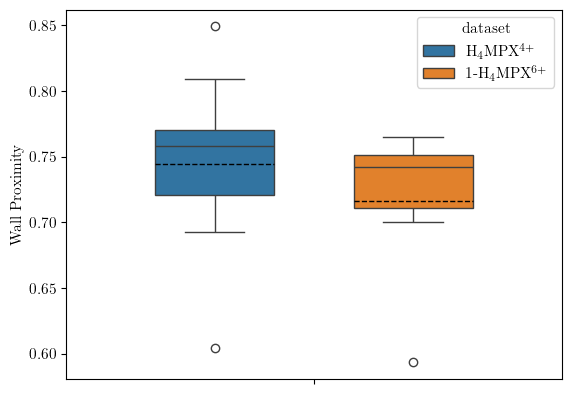

In [ ]:
combined = pd.concat([
    no_metal_rut_pep_pep_sum_no_15_df.assign(dataset="no metal single"),
    rut_pep_pep_sum_df.assign(dataset="single"),
    no_metal_double_pep_sum_df.assign(dataset="no metal double"),
    double_pep_sum_df.assign(dataset="double")
])

combined_rut = pd.concat([no_metal_rut_pep_pep_sum_no_15_df.assign(dataset="H$_4$MPX$^{4+}$"), rut_pep_pep_sum_df.assign(dataset="1-H$_4$MPX$^{6+}$")])
renamed_combined_rut = combined_rut.rename(columns={"mean_weighted_proximity_wall": "Wall Proximity",})

sns.boxplot(
    data=renamed_combined_rut,
    # title="double_pep_sum_df",
    # x="Dataset",
    y="Wall Proximity", 
    # col="dataset", 
    hue="dataset",
    showmeans=True,
    meanline=True,
    meanprops={"color": "black"},
    # label="metal",
    # ax=ax,
    # binwidth=10,
    # palette=["orange", "lightcoral"],
    # fill=True,
    legend=True,
    gap=0.4,
    )

# plt.savefig("/home/jacob/data_processing/data/plots/kde_plot_single.pgf")
plt.savefig("/home/jacob/data_processing/data/plots/box_plot_single.pdf", bbox_inches="tight")
plt.show()
# sns.scatterplot(
#     data=renamed_combined_rut,
#     # title="double_pep_sum_df",
#     x="Dataset",
#     y="Wall Proximity", 
#     # col="dataset", 
#     hue="Dataset",
#     # label="metal",
#     # ax=ax,
#     # binwidth=10,
#     # palette=["orange", "lightcoral"],
#     # fill=True,
#     legend=False,
#     )

# # plt.ylim(0.75, 2.75)
# plt.show()

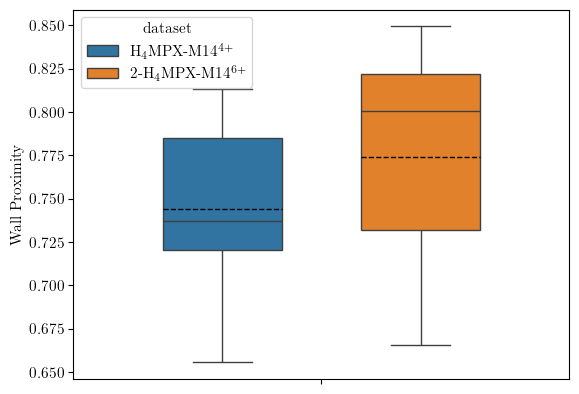

In [ ]:
combined = pd.concat([
    no_metal_rut_pep_pep_sum_no_15_df.assign(dataset="no metal single"),
    rut_pep_pep_sum_df.assign(dataset="single"),
    no_metal_double_pep_sum_df.assign(dataset="no metal double"),
    double_pep_sum_df.assign(dataset="double")
])

combined_rut = pd.concat([no_metal_double_pep_sum_df.assign(dataset="H$_4$MPX-M14$^{4+}$"), double_pep_sum_df.assign(dataset="2-H$_4$MPX-M14$^{6+}$")])
renamed_combined_double = combined_rut.rename(columns={"mean_weighted_proximity_wall": "Wall Proximity",})

sns.boxplot(
    data=renamed_combined_double,
    # title="double_pep_sum_df",
    # x="Dataset",
    y="Wall Proximity", 
    # col="dataset", 
    hue="dataset",
    showmeans=True,
    meanline=True,
    meanprops={"color": "black"},
    # label="metal",
    # ax=ax,
    # binwidth=10,
    # palette=["orange", "lightcoral"],
    # fill=True,
    legend=True,
    gap=0.4,
    )

# plt.savefig("/home/jacob/data_processing/data/plots/kde_plot_single.pgf")
plt.savefig("/home/jacob/data_processing/data/plots/box_plot_double.pdf", bbox_inches="tight")
plt.show()
# sns.scatterplot(
#     data=renamed_combined_rut,
#     # title="double_pep_sum_df",
#     x="Dataset",
#     y="Wall Proximity", 
#     # col="dataset", 
#     hue="Dataset",
#     # label="metal",
#     # ax=ax,
#     # binwidth=10,
#     # palette=["orange", "lightcoral"],
#     # fill=True,
#     legend=False,
#     )

# # plt.ylim(0.75, 2.75)
# plt.show()